### Cargar librerias

In [19]:
import pandas as pd
import numpy as np
import datetime as dt
import seaborn as sns 
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv('Datos/Transformados/df_limpio.csv')

In [21]:
df.head()

,booked_at,checkin_time,checkout_time,lead_time,lenght_of_stay,checkin_month,checkin_day,adult_count,child_count,origin,...,cancellation_lead_time,ciudad,mes_cancelacion,estacion_cancelacion,mes_estancia,estacion_estancia,espera_dias,meses_espera,espera_zona_roja,ratio_asistencia
0,2022-11-26 16:10:00,2023-01-01 12:00:00,2023-01-02 12:00:00,36,1,January,Sunday,1,0,channel_manager,...,NaN,Donosti,NaN,NaN,1,Invierno,35,"[11, 12]",0,1.0
1,2022-12-21 17:27:00,2023-01-01 13:09:00,2023-01-10 12:00:00,11,9,January,Sunday,1,0,channel_manager,...,NaN,Donosti,NaN,NaN,1,Invierno,10,[12],0,1.0
2,2022-09-21 19:46:00,2023-01-01 15:00:00,2023-01-07 12:00:00,102,6,January,Sunday,2,4,channel_manager,...,NaN,Donosti,NaN,NaN,1,Invierno,101,"[9, 10, 11, 12]",0,3.0
3,2022-09-24 12:09:00,2023-01-01 15:00:00,2023-01-02 12:00:00,99,1,January,Sunday,2,2,channel_manager,...,NaN,Donosti,NaN,NaN,1,Invierno,99,"[9, 10, 11, 12, 1]",1,2.0
4,2022-10-18 07:12:00,2023-01-01 15:00:00,2023-01-02 12:00:00,75,1,January,Sunday,4,0,channel_manager,...,NaN,Donosti,NaN,NaN,1,Invierno,75,"[10, 11, 12, 1]",1,1.0


In [22]:
df['booked_at'] = pd.to_datetime(df['booked_at'], format="mixed", errors="coerce")
df['checkin_time'] = pd.to_datetime(df['checkin_time'], format="mixed", errors="coerce")
df['checkout_time'] = pd.to_datetime(df['checkout_time'], format="mixed", errors="coerce")
df['asset_opening_date'] = pd.to_datetime(df['asset_opening_date'], format="mixed", errors="coerce")
df['cancelled_at'] = pd.to_datetime(df['cancelled_at'], format="mixed", errors="coerce")
df['last_entry_form_completed_at'] = pd.to_datetime(df['last_entry_form_completed_at'], format="mixed", errors="coerce")
df['completed_entry_forms_count'] = pd.to_numeric(df['completed_entry_forms_count'], errors="coerce")

In [23]:
cols_num = df.select_dtypes(include='number').columns
corr_matrix = df[cols_num].corr()
corr_matrix


,lead_time,lenght_of_stay,adult_count,child_count,available_units,completed_entry_forms_count,recurrence,product_count,reservation_net_value,total_adr,cancellation_lead_time,mes_cancelacion,mes_estancia,espera_dias,espera_zona_roja,ratio_asistencia
lead_time,1.000000,0.098732,0.220131,0.008439,0.031394,-0.104914,-0.040959,0.105714,0.176664,0.134558,0.718740,-0.034521,0.021632,0.999952,0.385056,0.059635
lenght_of_stay,0.098732,1.000000,-0.030339,-0.045253,-0.064304,-0.094576,0.009027,0.121244,0.448822,-0.078498,0.037680,-0.016076,-0.020783,0.098873,0.053247,-0.033664
adult_count,0.220131,-0.030339,1.000000,0.005376,-0.199744,0.529129,-0.070704,0.032290,0.330383,0.526133,0.089960,-0.010657,-0.034001,0.219987,0.121223,0.013595
child_count,0.008439,-0.045253,0.005376,1.000000,-0.014940,0.038282,-0.042275,0.099580,0.128699,0.246857,-0.026424,0.013283,0.028986,0.008158,0.036588,0.879059
available_units,0.031394,-0.064304,-0.199744,-0.014940,1.000000,-0.182626,0.048998,-0.022206,-0.356799,-0.375386,0.089746,-0.001719,0.033446,0.031481,0.011142,-0.004670
completed_entry_forms_count,-0.104914,-0.094576,0.529129,0.038282,-0.182626,1.000000,-0.031816,0.087972,0.166530,0.315399,-0.016531,0.017273,-0.006243,-0.105521,-0.022764,-0.032188
recurrence,-0.040959,0.009027,-0.070704,-0.042275,0.048998,-0.031816,1.000000,-0.034718,-0.044567,-0.050529,0.016197,-0.014841,0.017462,-0.040819,-0.035056,-0.040450
product_count,0.105714,0.121244,0.032290,0.099580,-0.022206,0.087972,-0.034718,1.000000,0.307983,0.190920,0.048775,0.019991,0.035025,0.105662,0.031415,0.097564
reservation_net_value,0.176664,0.448822,0.330383,0.128699,-0.356799,0.166530,-0.044567,0.307983,1.000000,0.626397,0.064669,0.070641,0.120139,0.176657,0.058295,0.118115
total_adr,0.134558,-0.078498,0.526133,0.246857,-0.375386,0.315399,-0.050529,0.190920,0.626397,1.000000,0.023852,0.063113,0.127231,0.134506,0.049454,0.230563


In [24]:
df_num = df.select_dtypes(include='number')
corr = df_num.corr()
corr

,lead_time,lenght_of_stay,adult_count,child_count,available_units,completed_entry_forms_count,recurrence,product_count,reservation_net_value,total_adr,cancellation_lead_time,mes_cancelacion,mes_estancia,espera_dias,espera_zona_roja,ratio_asistencia
lead_time,1.000000,0.098732,0.220131,0.008439,0.031394,-0.104914,-0.040959,0.105714,0.176664,0.134558,0.718740,-0.034521,0.021632,0.999952,0.385056,0.059635
lenght_of_stay,0.098732,1.000000,-0.030339,-0.045253,-0.064304,-0.094576,0.009027,0.121244,0.448822,-0.078498,0.037680,-0.016076,-0.020783,0.098873,0.053247,-0.033664
adult_count,0.220131,-0.030339,1.000000,0.005376,-0.199744,0.529129,-0.070704,0.032290,0.330383,0.526133,0.089960,-0.010657,-0.034001,0.219987,0.121223,0.013595
child_count,0.008439,-0.045253,0.005376,1.000000,-0.014940,0.038282,-0.042275,0.099580,0.128699,0.246857,-0.026424,0.013283,0.028986,0.008158,0.036588,0.879059
available_units,0.031394,-0.064304,-0.199744,-0.014940,1.000000,-0.182626,0.048998,-0.022206,-0.356799,-0.375386,0.089746,-0.001719,0.033446,0.031481,0.011142,-0.004670
completed_entry_forms_count,-0.104914,-0.094576,0.529129,0.038282,-0.182626,1.000000,-0.031816,0.087972,0.166530,0.315399,-0.016531,0.017273,-0.006243,-0.105521,-0.022764,-0.032188
recurrence,-0.040959,0.009027,-0.070704,-0.042275,0.048998,-0.031816,1.000000,-0.034718,-0.044567,-0.050529,0.016197,-0.014841,0.017462,-0.040819,-0.035056,-0.040450
product_count,0.105714,0.121244,0.032290,0.099580,-0.022206,0.087972,-0.034718,1.000000,0.307983,0.190920,0.048775,0.019991,0.035025,0.105662,0.031415,0.097564
reservation_net_value,0.176664,0.448822,0.330383,0.128699,-0.356799,0.166530,-0.044567,0.307983,1.000000,0.626397,0.064669,0.070641,0.120139,0.176657,0.058295,0.118115
total_adr,0.134558,-0.078498,0.526133,0.246857,-0.375386,0.315399,-0.050529,0.190920,0.626397,1.000000,0.023852,0.063113,0.127231,0.134506,0.049454,0.230563


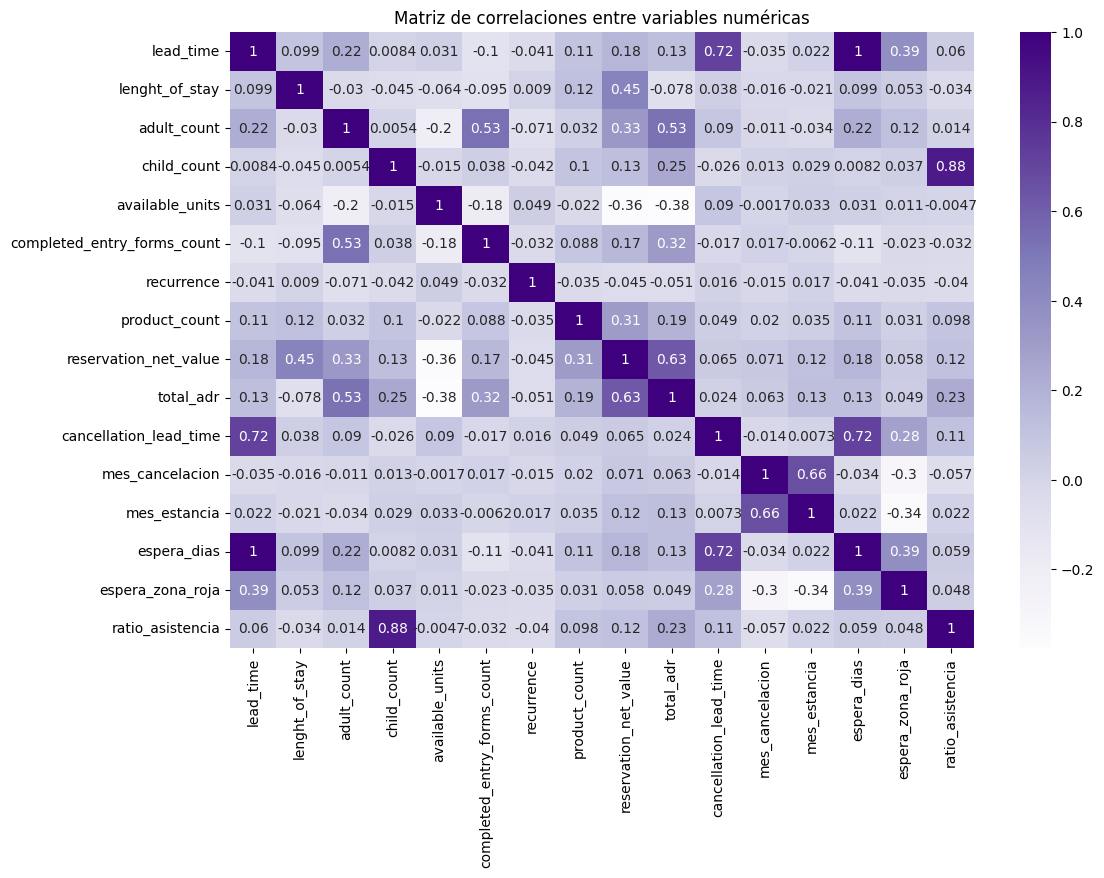

In [26]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='Purples', annot=True)
plt.title('Matriz de correlaciones entre variables numéricas')
plt.show()
